<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Unet/blob/main/UNET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!mkdir ~/.kaggle

In [3]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [4]:
!kaggle datasets download veeralakrishna/butterfly-dataset

Dataset URL: https://www.kaggle.com/datasets/veeralakrishna/butterfly-dataset
License(s): Community Data License Agreement - Permissive - Version 1.0
100% 454M/454M [00:14<00:00, 32.9MB/s]



In [6]:
!unzip /content/butterfly-dataset.zip -d /content/

Archive:  /content/butterfly-dataset.zip
  inflating: /content/leedsbutterfly/README.txt  
  inflating: /content/leedsbutterfly/descriptions/001.txt  
  inflating: /content/leedsbutterfly/descriptions/002.txt  
  inflating: /content/leedsbutterfly/descriptions/003.txt  
  inflating: /content/leedsbutterfly/descriptions/004.txt  
  inflating: /content/leedsbutterfly/descriptions/005.txt  
  inflating: /content/leedsbutterfly/descriptions/006.txt  
  inflating: /content/leedsbutterfly/descriptions/007.txt  
  inflating: /content/leedsbutterfly/descriptions/008.txt  
  inflating: /content/leedsbutterfly/descriptions/009.txt  
  inflating: /content/leedsbutterfly/descriptions/010.txt  
  inflating: /content/leedsbutterfly/images/0010001.png  
  inflating: /content/leedsbutterfly/images/0010002.png  
  inflating: /content/leedsbutterfly/images/0010004.png  
  inflating: /content/leedsbutterfly/images/0010005.png  
  inflating: /content/leedsbutterfly/images/0010006.png  
  inflating: /conte

In [17]:
import os
import re
import time

# Numerical Computing
import numpy as np

# Computer Vision
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
import tensorflow as tf
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    concatenate,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

%matplotlib inline

## Getting basic stats

In [31]:
image_path='/content/leedsbutterfly/images'
mask_path='/content/leedsbutterfly/segmentations'

In [32]:
#list image and masks
images=os.listdir(image_path)
masks=os.listdir(mask_path)

print(f"The data statistics \n images :{len(images)} masks: {len(masks)}")

The data statistics 
 images :832 masks: 832


In [33]:
#function to find the corresponding mask for given images
def get_corresponding_mask(image_name):
  base_name=image_name.split('.')[0]
  mask_name=f"{base_name}_seg0.png"
  return mask_name

In [34]:
#display few sample images
def show_samples(image_list,num_samples=3):
  plt.figure(figsize=(10,10))
  for i in range(num_samples):
    img=Image.open(os.path.join(image_path,image_list[i]))
    mask_name=get_corresponding_mask(image_list[i])
    mask=Image.open(os.path.join(mask_path,mask_name))

    plt.subplot(2,num_samples,i+1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2,num_samples, num_samples + i+1)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")
  plt.show()


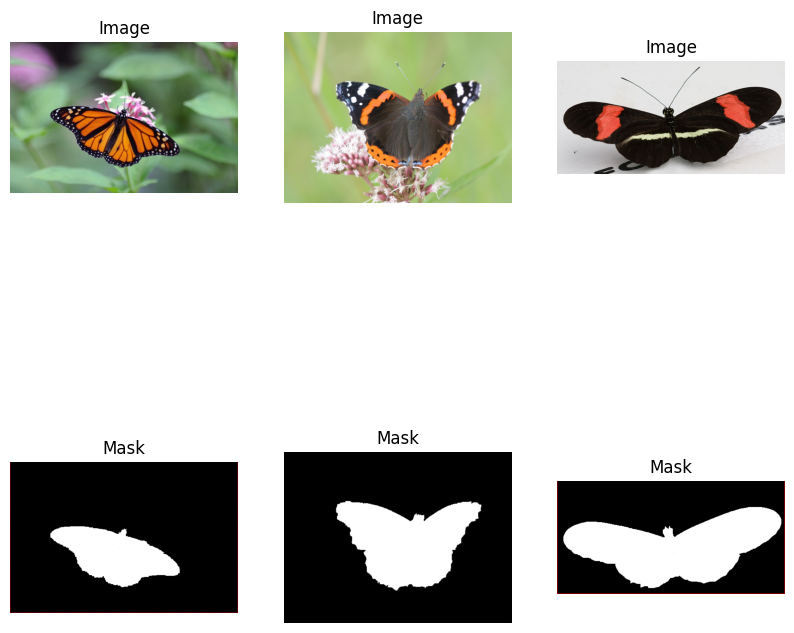

In [35]:
show_samples(images,num_samples=3)

## Load data

In [36]:
def load_data(image_dir, mask_dir, image_shape=256):
    """
    Loads and preprocesses images and masks for training.

    Args:
        image_dir (str): Directory containing the images.
        mask_dir (str): Directory containing the masks.
        image_shape (int, optional): Shape to resize the images and masks. Defaults to 256.

    Returns:
        tuple: Arrays of preprocessed images and masks.
    """
    image_list = []
    mask_list = []

    image_names = os.listdir(image_dir)
    mask_names = [re.sub(r'\.png', '_seg0.png', name) for name in image_names]

    for img_name, mask_name in zip(image_names, mask_names):
        try:
            img = plt.imread(os.path.join(image_dir, img_name))
            mask = plt.imread(os.path.join(mask_dir, mask_name))
        except FileNotFoundError:
            continue

        # Resizing the images and masks
        img_resized = cv2.resize(img, (image_shape, image_shape))
        mask_resized = cv2.resize(mask, (image_shape, image_shape))

        #storing the preprocessed data
        image_list.append(img_resized)
        mask_list.append(mask_resized[:, :,0])

    return np.array(image_list),np.array(mask_dir)

In [37]:
#load data
image_dir='/content/leedsbutterfly/images'
mask_dir='/content/leedsbutterfly/segmentations'
images,masks=load_data(image_dir,mask_dir)